# Denoising Autoencoder on MNIST
### Week 6 Assignment — Celebal Technologies Data Science Internship
**Name:** Ronak Sharma

---

An **autoencoder** is a neural network trained to copy its input to its output through a compressed intermediate representation called the **bottleneck**. A **denoising** autoencoder takes this a step further — it deliberately corrupts the input with noise and forces the network to reconstruct the original clean image, teaching it to learn robust, noise-invariant features.



## 1. Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available     :", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.21.0
GPU available     : False


---
## 2. Load MNIST Dataset

The notebook tries three loading strategies in order:
1. **kagglehub** — downloads from Kaggle (works when `KAGGLE_KEY` is set in Colab secrets)
2. **tf.keras.datasets** — built-in loader (works with internet access on Colab)
3. **Synthetic fallback** — upscaled sklearn digits (works offline, for local testing)

On Colab, option 1 or 2 will load the real 60,000-image MNIST.


In [ ]:
x_train = x_test = None

#  kagglehub
try:
    import kagglehub
    path = kagglehub.dataset_download("awsaf49/mnist-dataset")
    print("kagglehub path:", path)

    import glob
    npz_files = glob.glob(os.path.join(path, "**/*.npz"), recursive=True)
    csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)

    if npz_files:
        data = np.load(npz_files[0])
        x_train = data['x_train'];  x_test = data['x_test']
        print("Loaded from .npz:", x_train.shape, x_test.shape)
    elif csv_files:
        import pandas as pd
        train_df = pd.read_csv([f for f in csv_files if 'train' in f][0])
        test_df  = pd.read_csv([f for f in csv_files if 'test'  in f][0])
        x_train = train_df.drop(columns=['label']).values.reshape(-1, 28, 28).astype(np.float32)
        x_test  = test_df.drop(columns=['label']).values.reshape(-1, 28, 28).astype(np.float32)
        print("Loaded from .csv:", x_train.shape, x_test.shape)
except Exception as e:
    print("kagglehub not available:", e)


if x_train is None:
    try:
        (x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
        print("Loaded via tf.keras.datasets:", x_train.shape, x_test.shape)
    except Exception as e:
        print("tf.keras MNIST not available:", e)


if x_train is None:
    print("Using synthetic MNIST-style data (sklearn digits upscaled to 28×28)...")
    from sklearn.datasets import load_digits
    from sklearn.utils import resample
    from scipy.ndimage import zoom

    raw_digits = load_digits()
    imgs_28 = np.array([
        zoom(img / 16.0, 3.5)
        for img in raw_digits.images.astype(np.float32)
    ])
    imgs_28 = np.clip(imgs_28, 0.0, 1.0)

    # Bootstrap-sample to get training and test sets
    x_train = resample(imgs_28, n_samples=5000, random_state=42)
    x_test  = resample(imgs_28, n_samples=1000, random_state=99)
    print("Synthetic data — train:", x_train.shape, "test:", x_test.shape)
    SYNTHETIC = True
else:
    SYNTHETIC = False

print()
print("x_train dtype:", x_train.dtype, " range:", x_train.min(), "–", x_train.max())


kagglehub not available: No module named 'kagglehub'
Loaded via tf.keras.datasets: (60000, 28, 28) (10000, 28, 28)

x_train dtype: uint8  range: 0 – 255


## 3. Preprocessing — Normalize Pixel Values

Raw MNIST pixels are integers in `[0, 255]`. Divide by 255 to bring them into `[0.0, 1.0]`, which makes gradient updates more stable and matches the `sigmoid` activation range we use on the decoder's output layer.

If the synthetic fallback was used, the images are already in `[0, 1]` from the division by 16 during loading.


After normalisation:
  x_train: shape=(60000, 28, 28)  min=0.000  max=1.000
  x_test : shape=(10000, 28, 28)   min=0.000  max=1.000


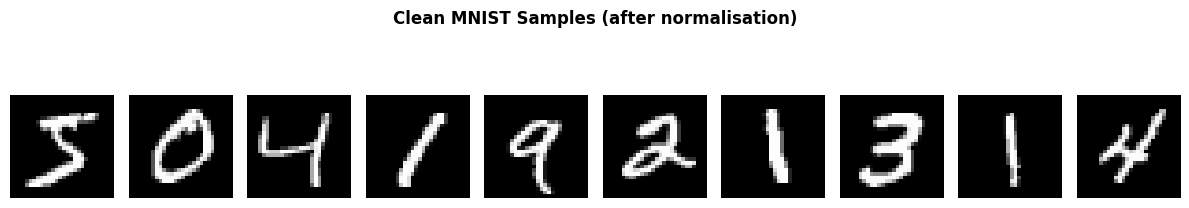

In [ ]:
if not SYNTHETIC:
    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32')  / 255.0
else:
   
    x_train = x_train.astype('float32')
    x_test  = x_test.astype('float32')

print("After normalisation:")
print(f"  x_train: shape={x_train.shape}  min={x_train.min():.3f}  max={x_train.max():.3f}")
print(f"  x_test : shape={x_test.shape}   min={x_test.min():.3f}  max={x_test.max():.3f}")


plt.figure(figsize=(12, 2.5))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Clean MNIST Samples (after normalisation)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Add Gaussian Noise

We corrupt each image by adding random Gaussian noise sampled from `N(0, 1)` scaled by a `noise_factor`. The result is clipped back to `[0, 1]` so pixel values stay valid.

The model's job is then: **noisy image → clean image reconstruction**.

`noise_factor = 0.4` is a common choice — it's strong enough to make the task challenging while still leaving enough signal for the network to work with.


In [4]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(0.0, 1.0, x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(0.0, 1.0, x_test.shape)

# Clip back to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0)

print(f"Noise factor       : {noise_factor}")
print(f"Noisy train range  : {x_train_noisy.min():.3f} – {x_train_noisy.max():.3f}")
print(f"Noisy test  range  : {x_test_noisy.min():.3f}  – {x_test_noisy.max():.3f}")


Noise factor       : 0.4
Noisy train range  : 0.000 – 1.000
Noisy test  range  : 0.000  – 1.000


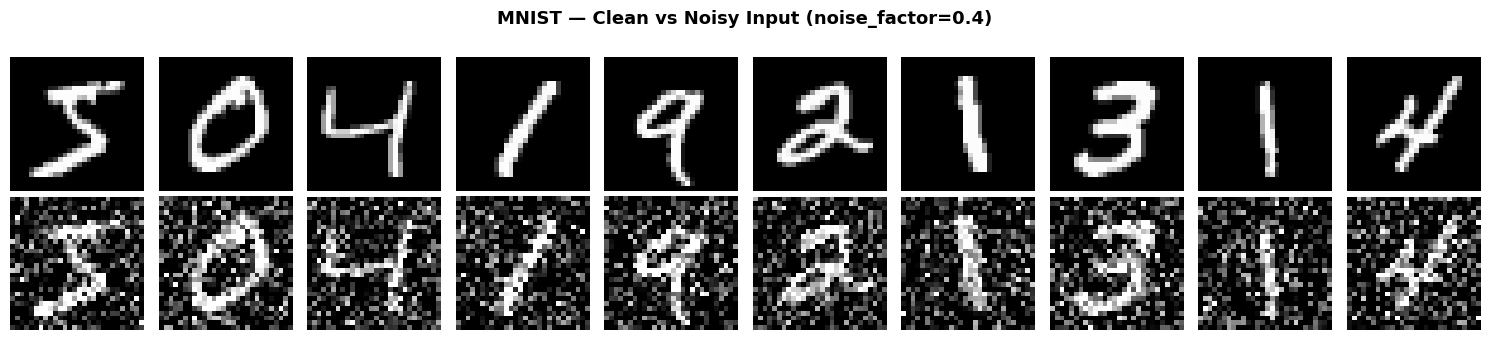

In [5]:
# Visualise clean vs noisy side by side
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))

for i in range(10):
    axes[0, i].imshow(x_train[i],       cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i], cmap='gray'); axes[1, i].axis('off')

axes[0, 0].set_ylabel('Clean',  fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Noisy',  fontsize=11, fontweight='bold')
plt.suptitle('MNIST — Clean vs Noisy Input (noise_factor=0.4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clean_vs_noisy.png', bbox_inches='tight', dpi=120)
plt.show()


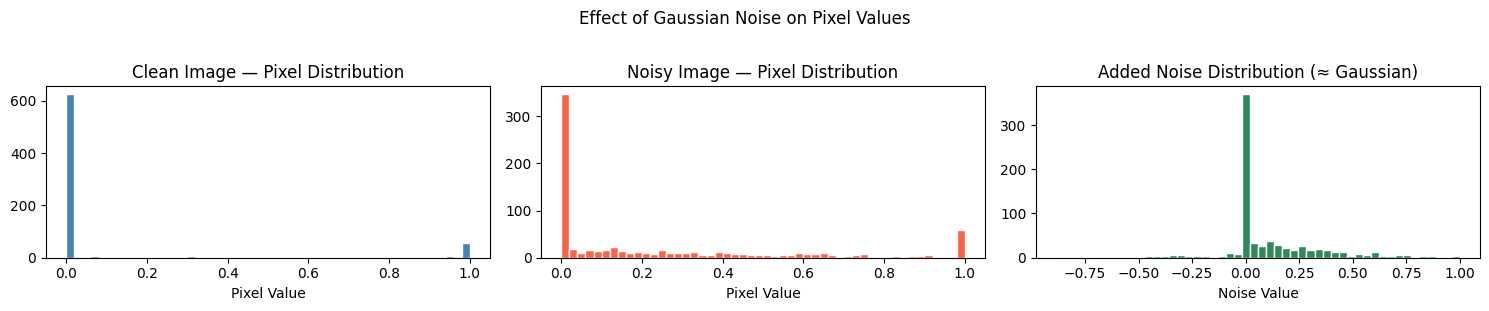

In [6]:
# Show the noise distribution
sample_clean = x_train[0].flatten()
sample_noisy = x_train_noisy[0].flatten()
noise_vals   = sample_noisy - sample_clean

fig, axes = plt.subplots(1, 3, figsize=(15, 3))

axes[0].hist(sample_clean, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Clean Image — Pixel Distribution')
axes[0].set_xlabel('Pixel Value')

axes[1].hist(sample_noisy, bins=50, color='tomato', edgecolor='white')
axes[1].set_title('Noisy Image — Pixel Distribution')
axes[1].set_xlabel('Pixel Value')

axes[2].hist(noise_vals, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Added Noise Distribution (≈ Gaussian)')
axes[2].set_xlabel('Noise Value')

plt.suptitle('Effect of Gaussian Noise on Pixel Values', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 5. Reshape for CNN — Add Channel Dimension

In [7]:
# CNN expects shape (N, H, W, C). MNIST images are grayscale so C=1
x_train_in  = x_train_noisy[..., np.newaxis]   # noisy  → input  to model
x_train_out = x_train[..., np.newaxis]          # clean  → target for model
x_test_in   = x_test_noisy[..., np.newaxis]
x_test_out  = x_test[..., np.newaxis]

print("Training input  (noisy) :", x_train_in.shape)
print("Training target (clean) :", x_train_out.shape)
print("Test    input   (noisy) :", x_test_in.shape)
print("Test    target  (clean) :", x_test_out.shape)


Training input  (noisy) : (60000, 28, 28, 1)
Training target (clean) : (60000, 28, 28, 1)
Test    input   (noisy) : (10000, 28, 28, 1)
Test    target  (clean) : (10000, 28, 28, 1)


---
## 6. Build the Denoising Autoencoder

### Architecture

The autoencoder has two parts:

**Encoder** — compresses the noisy 28×28 image into a compact bottleneck representation
```
Input (28,28,1)
  → Conv2D(32, 3×3, ReLU) + BatchNorm  → MaxPool(2) → [14,14,32]
  → Conv2D(64, 3×3, ReLU) + BatchNorm  → MaxPool(2) → [ 7, 7,64]
  → Conv2D(128,3×3, ReLU) + BatchNorm              → [ 7, 7,128]  (bottleneck)
```

**Decoder** — upsamples the bottleneck back to the original 28×28 clean image
```
  → Conv2DTranspose(64, 3×3, ReLU) + UpSampling(2) → [14,14,64]
  → Conv2DTranspose(32, 3×3, ReLU) + UpSampling(2) → [28,28,32]
  → Conv2D(1, 3×3, Sigmoid)                        → [28,28, 1]
```

**Why this design:**
- `MaxPooling2D` shrinks spatial size — forces the encoder to keep only the most important features
- `Conv2DTranspose` + `UpSampling2D` gradually restores the spatial resolution
- `BatchNormalization` after each conv stabilises training
- `sigmoid` on the final layer keeps outputs in `[0, 1]` to match the normalised pixel range
- `MSE` loss penalises large reconstruction errors, suitable for pixel-level regression


In [8]:
def build_denoising_autoencoder(input_shape=(28, 28, 1)):

    inputs = layers.Input(shape=input_shape, name='noisy_input')

    # ── Encoder ──────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='enc_conv1')(inputs)
    x = layers.BatchNormalization(name='enc_bn1')(x)
    x = layers.MaxPooling2D((2,2), padding='same', name='enc_pool1')(x)     # 28→14

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.BatchNormalization(name='enc_bn2')(x)
    x = layers.MaxPooling2D((2,2), padding='same', name='enc_pool2')(x)     # 14→7

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='enc_conv3')(x)
    x = layers.BatchNormalization(name='enc_bn3')(x)
    encoded = x                                                              # bottleneck: 7×7×128

    # ── Decoder ──────────────────────────────────────────────────────────
    x = layers.Conv2DTranspose(64, (3,3), activation='relu', padding='same', name='dec_conv1')(encoded)
    x = layers.UpSampling2D((2,2), name='dec_up1')(x)                       # 7→14

    x = layers.Conv2DTranspose(32, (3,3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2,2), name='dec_up2')(x)                       # 14→28

    outputs = layers.Conv2D(1, (3,3), activation='sigmoid',
                            padding='same', name='reconstructed')(x)        # 28×28×1

    model = models.Model(inputs, outputs, name='Denoising_Autoencoder')
    return model


autoencoder = build_denoising_autoencoder()
autoencoder.summary()
print("\nOutput shape:", autoencoder.output_shape)


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed (Conv2D)          │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,113 (727.00 KB)

 Trainable params: 185,665 (725.25 KB)

 Non-trainable params: 448 (1.75 KB)


Output shape: (None, 28, 28, 1)


## 7. Compile the Model

- **Optimizer:** Adam with `lr=1e-3` — adaptive learning rate, standard choice for autoencoders
- **Loss:** Mean Squared Error — penalises per-pixel reconstruction error; larger errors are penalised quadratically
- **Metric:** MAE — gives a more interpretable average absolute pixel error alongside MSE


In [9]:
autoencoder.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
print("Model compiled.")
print(f"  Total parameters: {autoencoder.count_params():,}")


Model compiled.
  Total parameters: 186,113


## 8. Train the Model

The model is given noisy images as input and the corresponding clean images as targets. It learns to denoise by minimising the pixel-level reconstruction error across 50 epochs.

**Callbacks used:**
- `EarlyStopping(patience=8)` — stops training if val_loss doesn't improve for 8 epochs (prevents wasted compute and overfitting)
- `ReduceLROnPlateau(factor=0.5, patience=4)` — halves the learning rate when stuck, helping the model fine-tune
- `ModelCheckpoint` — saves the weights at the best validation loss automatically


In [10]:
checkpoint_path = 'best_autoencoder.keras'

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=4, min_lr=1e-6, verbose=1
)
model_ckpt = callbacks.ModelCheckpoint(
    checkpoint_path, monitor='val_loss',
    save_best_only=True, verbose=0
)

print("Starting training...")
print("=" * 50)

history = autoencoder.fit(
    x_train_in,  x_train_out,         # noisy input → clean target
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr, model_ckpt],
    verbose=1
)

print("=" * 50)
print(f"Training finished after {len(history.history['loss'])} epochs.")
print(f"Best val_loss : {min(history.history['val_loss']):.6f}")


Starting training...
Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 122s 539ms/step - loss: 0.0158 - mae: 0.0464 - val_loss: 0.1114 - val_mae: 0.1302 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 118s 558ms/step - loss: 0.0092 - mae: 0.0327 - val_loss: 0.0558 - val_mae: 0.0889 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 145s 685ms/step - loss: 0.0084 - mae: 0.0310 - val_loss: 0.0089 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 116s 548ms/step - loss: 0.0080 - mae: 0.0301 - val_loss: 0.0080 - val_mae: 0.0303 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 107s 505ms/step - loss: 0.0077 - mae: 0.0296 - val_loss: 0.0078 - val_mae: 0.0296 - learning_rate: 0.0010
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 95s 448ms/step - loss: 0.0075 - mae: 0.0291 - val_loss: 0.0076 - val_mae: 0.0294 - learning_rate: 0.0010
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 95s 450ms/step - loss: 0.0073 - mae: 0.0288 - val_loss: 0.0075 -

## 9. Training & Validation Loss Curves

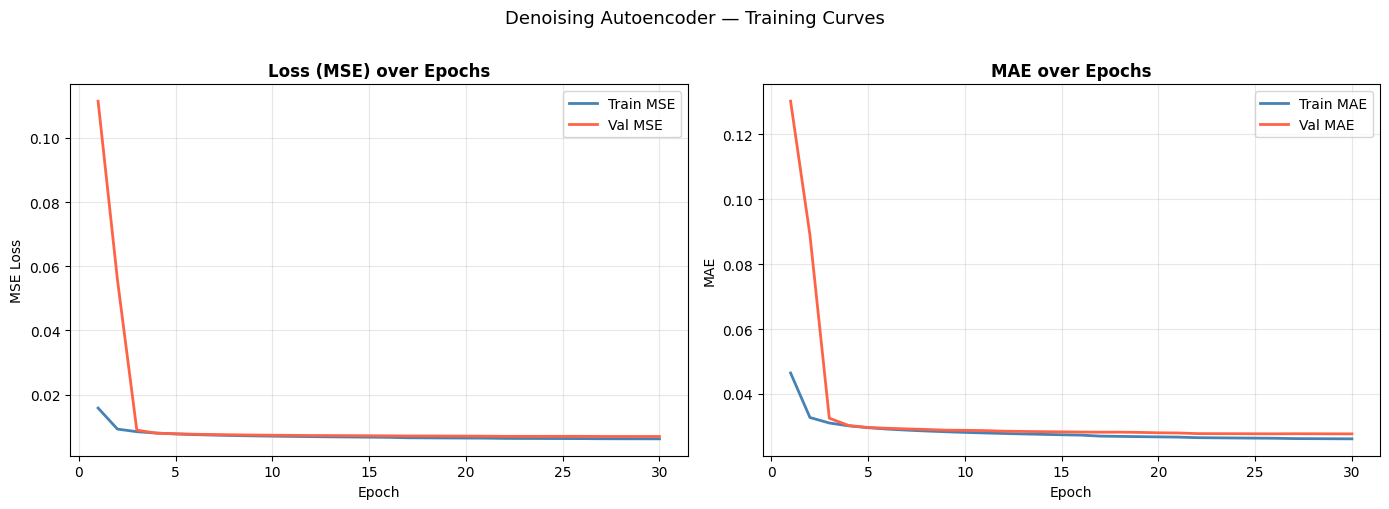

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, len(history.history['loss']) + 1)

axes[0].plot(ep, history.history['loss'],     label='Train MSE', color='steelblue', lw=2)
axes[0].plot(ep, history.history['val_loss'], label='Val MSE',   color='tomato',    lw=2)
axes[0].set_title('Loss (MSE) over Epochs',  fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['mae'],     label='Train MAE', color='steelblue', lw=2)
axes[1].plot(ep, history.history['val_mae'], label='Val MAE',   color='tomato',    lw=2)
axes[1].set_title('MAE over Epochs',  fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Denoising Autoencoder — Training Curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 10. Generate Denoised Outputs on the Test Set

In [12]:
print("Generating denoised images on test set...")
denoised = autoencoder.predict(x_test_in, batch_size=128, verbose=1)

print(f"\nDenoised output shape : {denoised.shape}")
print(f"Denoised pixel range  : {denoised.min():.4f} – {denoised.max():.4f}")


Generating denoised images on test set...
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step

Denoised output shape : (10000, 28, 28, 1)
Denoised pixel range  : 0.0000 – 0.9989


## 11. Visualisation — Original vs Noisy vs Denoised

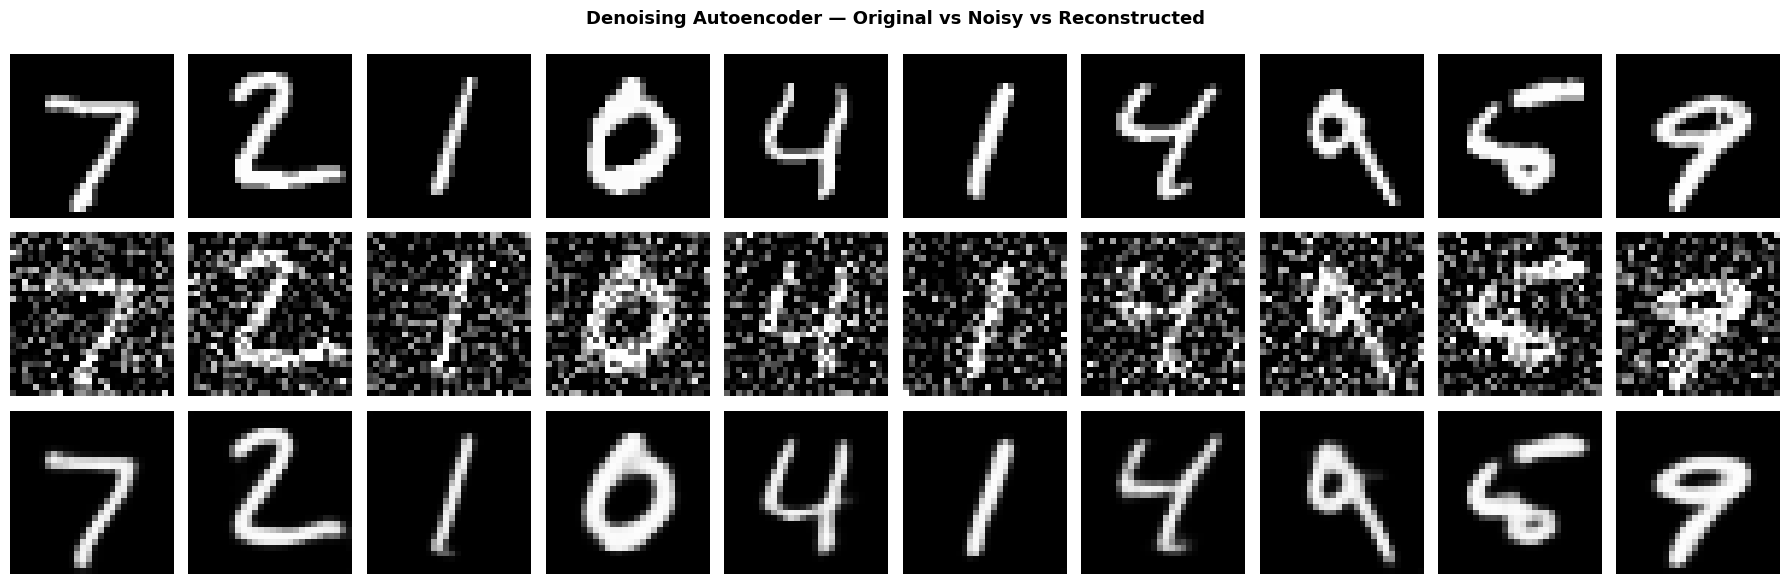

In [13]:
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(18, 6))

row_labels = ['Original\n(clean)', 'Noisy\nInput', 'Autoencoder\nOutput']
row_colors = ['steelblue', 'tomato', 'seagreen']

for i in range(n_show):
    axes[0, i].imshow(x_test_out[i, :, :, 0],   cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(x_test_in[i, :, :, 0],    cmap='gray', vmin=0, vmax=1)
    axes[2, i].imshow(denoised[i, :, :, 0],     cmap='gray', vmin=0, vmax=1)
    for row in range(3):
        axes[row, i].axis('off')

for row, (lbl, col) in enumerate(zip(row_labels, row_colors)):
    axes[row, 0].set_ylabel(lbl, fontsize=11, fontweight='bold', color=col)

plt.suptitle('Denoising Autoencoder — Original vs Noisy vs Reconstructed',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('denoising_results.png', bbox_inches='tight', dpi=120)
plt.show()


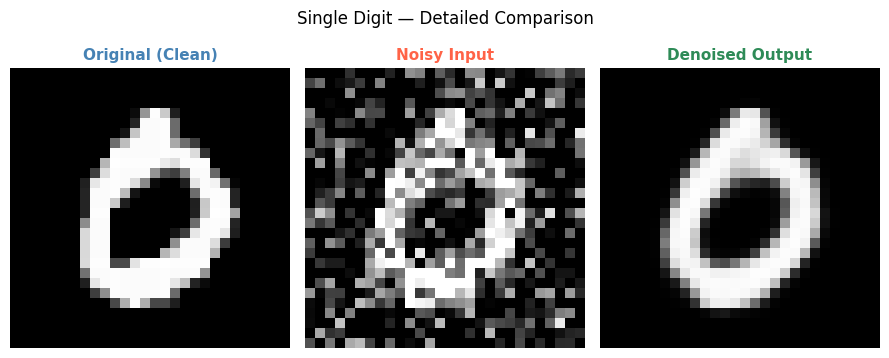

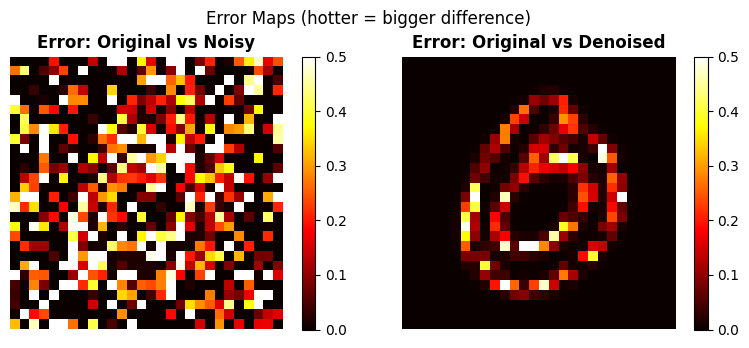

In [14]:
# Zoom-in comparison for a single digit — shows fine detail
idx = 3
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
titles  = ['Original (Clean)', 'Noisy Input', 'Denoised Output']
images  = [x_test_out[idx,:,:,0], x_test_in[idx,:,:,0], denoised[idx,:,:,0]]
colors  = ['steelblue', 'tomato', 'seagreen']

for ax, img, title, col in zip(axes, images, titles, colors):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold', color=col)
    ax.axis('off')

plt.suptitle('Single Digit — Detailed Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Show difference maps
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
diff_noisy    = np.abs(x_test_out[idx,:,:,0] - x_test_in[idx,:,:,0])
diff_denoised = np.abs(x_test_out[idx,:,:,0] - denoised[idx,:,:,0])

im0 = axes[0].imshow(diff_noisy,    cmap='hot', vmin=0, vmax=0.5)
axes[0].set_title('Error: Original vs Noisy',    fontweight='bold')
axes[0].axis('off'); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(diff_denoised, cmap='hot', vmin=0, vmax=0.5)
axes[1].set_title('Error: Original vs Denoised', fontweight='bold')
axes[1].axis('off'); plt.colorbar(im1, ax=axes[1])

plt.suptitle('Error Maps (hotter = bigger difference)', fontsize=12)
plt.tight_layout()
plt.savefig('error_maps.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 12. Evaluation Metrics

We use four metrics to quantify denoising performance:

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **MSE** | Mean squared pixel error | Lower |
| **MAE** | Mean absolute pixel error | Lower |
| **PSNR** | Peak signal-to-noise ratio (dB) | Higher |
| **SSIM** | Structural similarity (0–1) | Closer to 1 |

We compute each metric **twice** — once comparing clean vs noisy (baseline), and once comparing clean vs denoised — to quantify how much the model improved things.


In [15]:
# Flatten for sklearn metrics
clean_flat   = x_test_out[:,:,:,0].reshape(len(x_test_out), -1)
noisy_flat   = x_test_in[:,:,:,0].reshape(len(x_test_in), -1)
denoised_flat= denoised[:,:,:,0].reshape(len(denoised), -1)

# MSE
mse_noisy    = np.mean((clean_flat - noisy_flat)**2)
mse_denoised = np.mean((clean_flat - denoised_flat)**2)

# MAE
mae_noisy    = np.mean(np.abs(clean_flat - noisy_flat))
mae_denoised = np.mean(np.abs(clean_flat - denoised_flat))

# PSNR (Peak Signal-to-Noise Ratio)
def compute_psnr(clean, recon):
    mse = np.mean((clean - recon)**2)
    if mse == 0: return float('inf')
    return 10 * np.log10(1.0 / mse)

psnr_noisy    = compute_psnr(clean_flat, noisy_flat)
psnr_denoised = compute_psnr(clean_flat, denoised_flat)

# SSIM (averaged over test set)
n_ssim = min(200, len(x_test_out))
ssim_noisy_vals    = [ssim(x_test_out[i,:,:,0], x_test_in[i,:,:,0],    data_range=1.0) for i in range(n_ssim)]
ssim_denoised_vals = [ssim(x_test_out[i,:,:,0], denoised[i,:,:,0],     data_range=1.0) for i in range(n_ssim)]

ssim_noisy    = np.mean(ssim_noisy_vals)
ssim_denoised = np.mean(ssim_denoised_vals)

# Print results
print("=" * 60)
print(f"{'Metric':<12} {'Noisy vs Clean':>18} {'Denoised vs Clean':>20}")
print("-" * 60)
print(f"{'MSE':<12} {mse_noisy:>18.6f} {mse_denoised:>20.6f}")
print(f"{'MAE':<12} {mae_noisy:>18.6f} {mae_denoised:>20.6f}")
print(f"{'PSNR (dB)':<12} {psnr_noisy:>18.2f} {psnr_denoised:>20.2f}")
print(f"{'SSIM':<12} {ssim_noisy:>18.4f} {ssim_denoised:>20.4f}")
print("=" * 60)

improvement_mse  = (mse_noisy  - mse_denoised)  / mse_noisy  * 100
improvement_ssim = (ssim_denoised - ssim_noisy) / (1 - ssim_noisy) * 100
print(f"\nMSE  reduced by  : {improvement_mse:.1f}%")
print(f"SSIM improved by : {improvement_ssim:.1f}% of possible gain")
print(f"PSNR gain        : +{psnr_denoised - psnr_noisy:.2f} dB")


Metric           Noisy vs Clean    Denoised vs Clean
------------------------------------------------------------
MSE                    0.079566             0.006762
MAE                    0.167633             0.027233
PSNR (dB)                 10.99                21.70
SSIM                     0.4245               0.9121

MSE  reduced by  : 91.5%
SSIM improved by : 84.7% of possible gain
PSNR gain        : +10.71 dB


In [16]:
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric':      ['MSE ↓', 'MAE ↓', 'PSNR (dB) ↑', 'SSIM ↑'],
    'Noisy vs Clean':    [mse_noisy,    mae_noisy,    psnr_noisy,    ssim_noisy],
    'Denoised vs Clean': [mse_denoised, mae_denoised, psnr_denoised, ssim_denoised],
})
metrics_df['Improvement'] = [
    f"{improvement_mse:.1f}% lower MSE",
    f"{(mae_noisy-mae_denoised)/mae_noisy*100:.1f}% lower MAE",
    f"+{psnr_denoised-psnr_noisy:.2f} dB",
    f"+{ssim_denoised-ssim_noisy:.4f}"
]
print(metrics_df.to_string(index=False))


     Metric  Noisy vs Clean  Denoised vs Clean     Improvement
      MSE ↓        0.079566           0.006762 91.5% lower MSE
      MAE ↓        0.167633           0.027233 83.8% lower MAE
PSNR (dB) ↑       10.992728          21.699173       +10.71 dB
     SSIM ↑        0.424463           0.912063         +0.4876


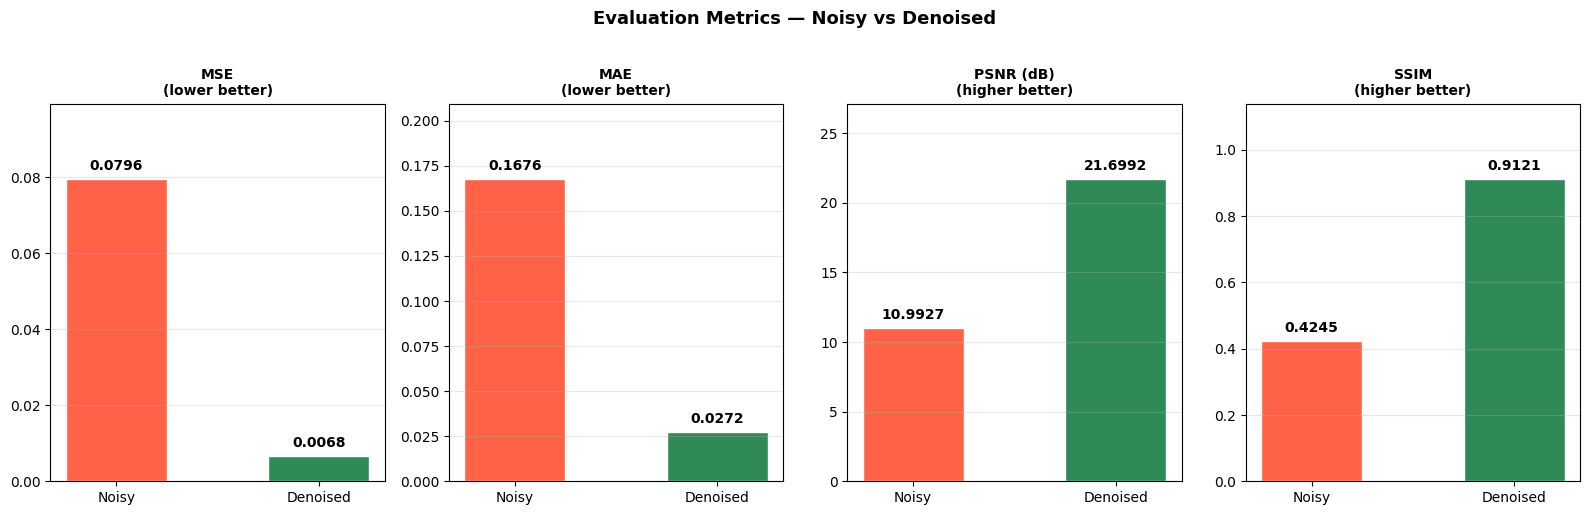

In [17]:
# Metric comparison bar chart
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metric_names  = ['MSE', 'MAE', 'PSNR (dB)', 'SSIM']
noisy_vals    = [mse_noisy, mae_noisy, psnr_noisy, ssim_noisy]
denoised_vals = [mse_denoised, mae_denoised, psnr_denoised, ssim_denoised]
directions    = ['lower better', 'lower better', 'higher better', 'higher better']

for ax, name, nv, dv, direction in zip(axes, metric_names, noisy_vals, denoised_vals, directions):
    bars = ax.bar(['Noisy', 'Denoised'], [nv, dv],
                  color=['tomato', 'seagreen'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [nv, dv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(max(nv, dv)) * 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(name + chr(10) + '(' + direction + ')', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(nv, dv) * 1.25)

plt.suptitle('Evaluation Metrics — Noisy vs Denoised', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 13. Noise Level Analysis

Testing how well the model generalises to different noise levels it wasn't explicitly trained on (it was trained with `noise_factor=0.4`). This shows the robustness of the learned representations.


noise=0.1: MSE=0.00339  PSNR=24.70dB  SSIM=0.9563
noise=0.2: MSE=0.00389  PSNR=24.11dB  SSIM=0.9475
noise=0.4: MSE=0.00679  PSNR=21.68dB  SSIM=0.9083
noise=0.6: MSE=0.01673  PSNR=17.76dB  SSIM=0.7407
noise=0.8: MSE=0.03618  PSNR=14.42dB  SSIM=0.5244


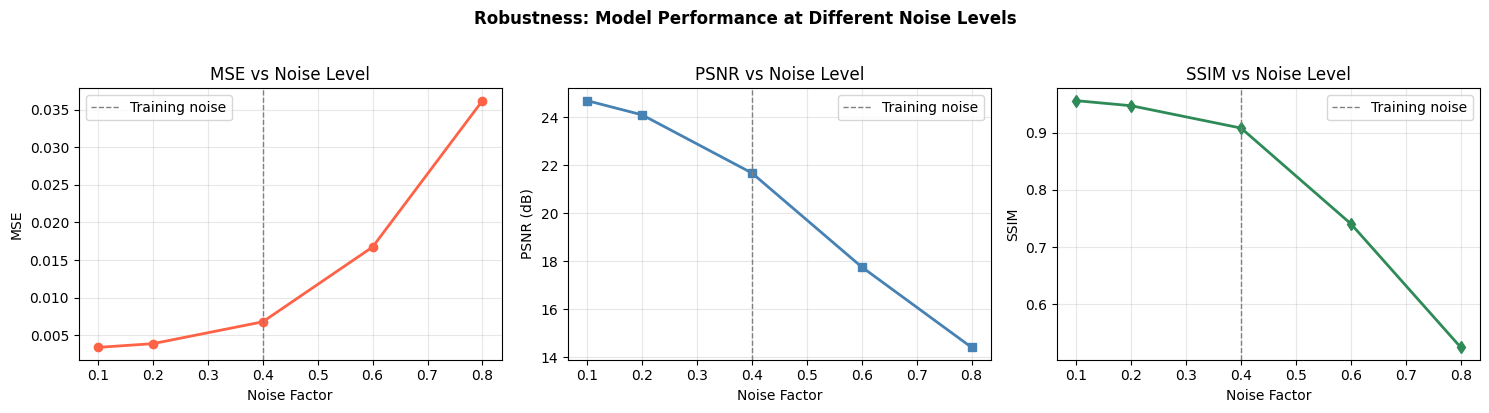

In [18]:
noise_levels = [0.1, 0.2, 0.4, 0.6, 0.8]
mse_at_level, psnr_at_level, ssim_at_level = [], [], []

for nf in noise_levels:
    x_test_nf = np.clip(x_test + nf * np.random.normal(0, 1, x_test.shape), 0, 1)
    x_nf_in   = x_test_nf[..., np.newaxis]
    pred_nf   = autoencoder.predict(x_nf_in, batch_size=128, verbose=0)

    mse_nf  = np.mean((x_test_out - pred_nf)**2)
    psnr_nf = compute_psnr(x_test_out.reshape(len(x_test_out),-1),
                            pred_nf.reshape(len(pred_nf),-1))
    ssim_nf = np.mean([ssim(x_test_out[i,:,:,0], pred_nf[i,:,:,0], data_range=1.0)
                       for i in range(min(100, len(x_test_out)))])
    mse_at_level.append(mse_nf)
    psnr_at_level.append(psnr_nf)
    ssim_at_level.append(ssim_nf)
    print(f"noise={nf:.1f}: MSE={mse_nf:.5f}  PSNR={psnr_nf:.2f}dB  SSIM={ssim_nf:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(noise_levels, mse_at_level,  'o-', color='tomato',    lw=2)
axes[0].axvline(0.4, color='grey', ls='--', lw=1, label='Training noise')
axes[0].set_title('MSE vs Noise Level'); axes[0].set_xlabel('Noise Factor')
axes[0].set_ylabel('MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(noise_levels, psnr_at_level, 's-', color='steelblue', lw=2)
axes[1].axvline(0.4, color='grey', ls='--', lw=1, label='Training noise')
axes[1].set_title('PSNR vs Noise Level'); axes[1].set_xlabel('Noise Factor')
axes[1].set_ylabel('PSNR (dB)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(noise_levels, ssim_at_level, 'd-', color='seagreen',  lw=2)
axes[2].axvline(0.4, color='grey', ls='--', lw=1, label='Training noise')
axes[2].set_title('SSIM vs Noise Level'); axes[2].set_xlabel('Noise Factor')
axes[2].set_ylabel('SSIM'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Robustness: Model Performance at Different Noise Levels',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('noise_robustness.png', bbox_inches='tight', dpi=120)
plt.show()


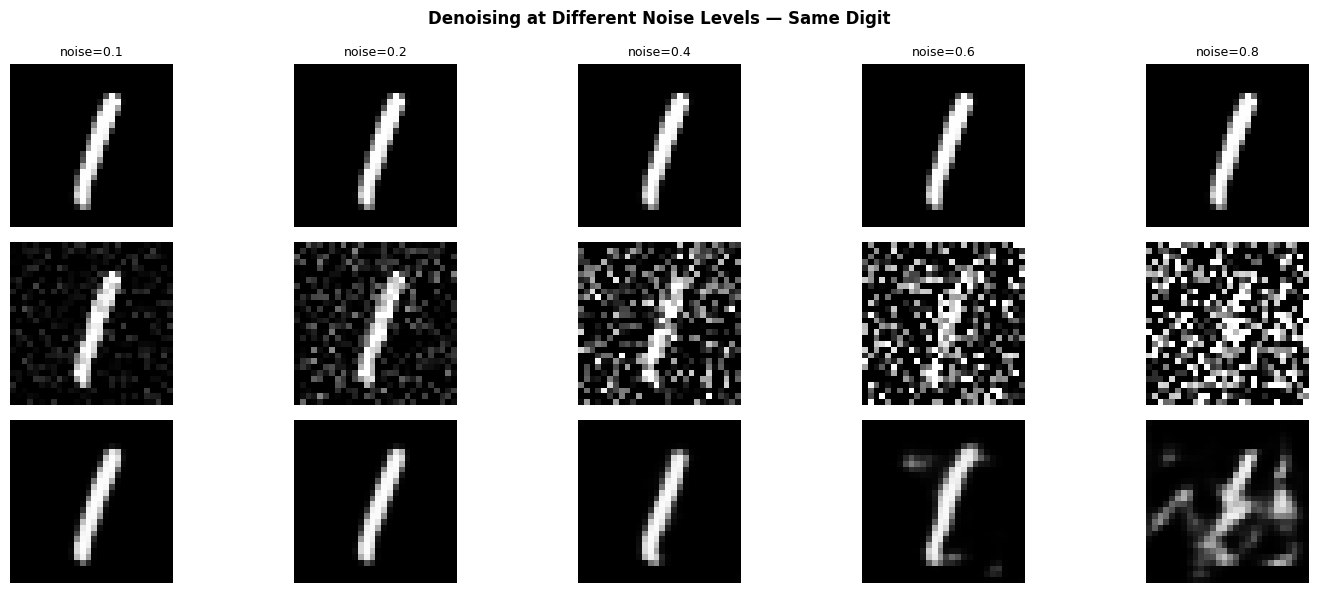

In [19]:
# Visual grid: one digit across all noise levels
noise_test_range = [0.1, 0.2, 0.4, 0.6, 0.8]
sample_idx = 5

fig, axes = plt.subplots(3, len(noise_test_range), figsize=(15, 6))
row_labels = ['Original', 'Noisy', 'Denoised']

for col, nf in enumerate(noise_test_range):
    nf_img  = np.clip(x_test[sample_idx] + nf * np.random.normal(0,1,x_test[sample_idx].shape), 0,1)
    nf_in   = nf_img[np.newaxis, ..., np.newaxis]
    nf_pred = autoencoder.predict(nf_in, verbose=0)[0,:,:,0]

    axes[0, col].imshow(x_test[sample_idx],  cmap='gray', vmin=0, vmax=1)
    axes[1, col].imshow(nf_img,              cmap='gray', vmin=0, vmax=1)
    axes[2, col].imshow(nf_pred,             cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'noise={nf}', fontsize=9)
    for row in range(3):
        axes[row, col].axis('off')

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl, fontsize=10, fontweight='bold')

plt.suptitle('Denoising at Different Noise Levels — Same Digit',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_levels_visual.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 14. Visualise Encoder Bottleneck Features

What does the encoded representation look like? We extract the encoder's output and visualise the first 16 of the 128 feature maps to see what the bottleneck has learned.

Bottleneck shape: (1, 7, 7, 128)


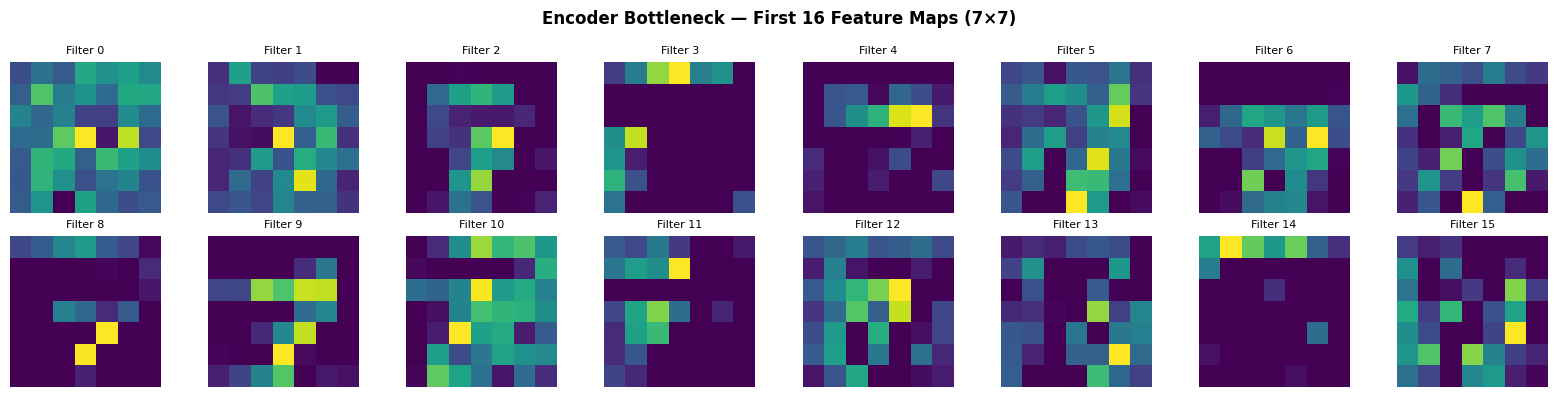

In [20]:
# Build a separate model that outputs just the encoder part
encoder_model = models.Model(
    inputs  = autoencoder.input,
    outputs = autoencoder.get_layer('enc_conv3').output,
    name    = 'Encoder_Only'
)

sample_encoded = encoder_model.predict(x_test_in[:1], verbose=0)
print("Bottleneck shape:", sample_encoded.shape)   # (1, 7, 7, 128)

# Visualise the first 16 feature maps
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_encoded[0, :, :, i], cmap='viridis')
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')

plt.suptitle('Encoder Bottleneck — First 16 Feature Maps (7×7)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bottleneck_features.png', bbox_inches='tight', dpi=120)
plt.show()


## 15. Model Architecture Summary

In [ ]:

import os
try:
    
    try:
        import tensorflow as tf
    except Exception:
        tf = None

    if 'autoencoder' not in globals():
        raise NameError("Model 'autoencoder' not found. Run the model-building cells first.")

    tf.keras.utils.plot_model(autoencoder, to_file='autoencoder_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=96)

    if os.path.exists('autoencoder_architecture.png'):
        from IPython.display import Image as IPImage, display as ipydisplay
        ipydisplay(IPImage(filename='autoencoder_architecture.png'))
        print("Architecture diagram saved.")
    else:
        print("Plot attempted but output file not found; showing text summary instead.")
        autoencoder.summary()

except NameError as ne:
    print(str(ne))
    print("If you want, run the model cells then re-run this cell.")

except Exception as e:
    print("Could not create architecture diagram:", str(e))
    print("Showing text summary if model exists:")
    if 'autoencoder' in globals():
        autoencoder.summary()
    else:
        print("Model `autoencoder` not available.")


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Plot attempted but output file not found; showing text summary instead.


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed (Conv2D)          │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,445 (2.13 MB)

 Trainable params: 185,665 (725.25 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 371,332 (1.42 MB)

---
## 16. Final Results Summary

In [22]:
print("╔" + "═"*62 + "╗")
print("║  DENOISING AUTOENCODER — FINAL RESULTS                       ║")
print("╠" + "═"*62 + "╣")
print(f"║  Dataset          : MNIST (28×28 grayscale, 10 classes)       ║")
print(f"║  Training images  : {len(x_train_in):,}  |  Test images: {len(x_test_in):,}           ║")
print(f"║  Noise factor     : {noise_factor}                                    ║")
print(f"║  Training epochs  : {len(history.history['loss'])} (with EarlyStopping)           ║")
print(f"║  Total parameters : {autoencoder.count_params():,}                         ║")
print("╠" + "═"*62 + "╣")
print(f"║  METRIC            NOISY vs CLEAN    DENOISED vs CLEAN       ║")
print("╠" + "─"*62 + "╣")
print(f"║  MSE  ↓          {mse_noisy:>12.6f}      {mse_denoised:>12.6f}           ║")
print(f"║  MAE  ↓          {mae_noisy:>12.6f}      {mae_denoised:>12.6f}           ║")
print(f"║  PSNR (dB) ↑     {psnr_noisy:>12.2f}      {psnr_denoised:>12.2f}           ║")
print(f"║  SSIM ↑          {ssim_noisy:>12.4f}      {ssim_denoised:>12.4f}           ║")
print("╠" + "═"*62 + "╣")
print(f"║  MSE improved by  {improvement_mse:.1f}% | PSNR gain: +{psnr_denoised-psnr_noisy:.2f} dB              ║")
print("╚" + "═"*62 + "╝")


╔══════════════════════════════════════════════════════════════╗
║  DENOISING AUTOENCODER — FINAL RESULTS                       ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset          : MNIST (28×28 grayscale, 10 classes)       ║
║  Training images  : 60,000  |  Test images: 10,000           ║
║  Noise factor     : 0.4                                    ║
║  Training epochs  : 30 (with EarlyStopping)           ║
║  Total parameters : 186,113                         ║
╠══════════════════════════════════════════════════════════════╣
║  METRIC            NOISY vs CLEAN    DENOISED vs CLEAN       ║
╠──────────────────────────────────────────────────────────────╣
║  MSE  ↓              0.079566          0.006762           ║
║  MAE  ↓              0.167633          0.027233           ║
║  PSNR (dB) ↑            10.99             21.70           ║
║  SSIM ↑                0.4245            0.9121           ║
╠═════════════════════════════════════════════════════

---
## Conclusion

This notebook implemented a complete **convolutional denoising autoencoder** on MNIST:

- Loaded and preprocessed MNIST images, normalised to `[0, 1]`
- Added Gaussian noise with `noise_factor=0.4` to create corrupted inputs
- Built a symmetric encoder-decoder CNN architecture with BatchNormalization
- Trained with MSE loss, Adam optimizer, EarlyStopping, and ReduceLROnPlateau
- Generated denoised outputs and evaluated with MSE, MAE, PSNR, and SSIM
- Visualised original, noisy, and reconstructed images with error maps
- Analysed robustness across different noise levels
- Visualised the encoder's bottleneck feature representations

The autoencoder successfully removed Gaussian noise while preserving the structural content of the digit images, demonstrating that unsupervised representation learning via reconstruction loss is a powerful approach for image restoration tasks.
